In [1]:
import mlflow
import shap

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_csv("../data/processed/raw_features/X_train.csv")
X_test = pd.read_csv("../data/processed/raw_features/X_test.csv")
y_train = pd.read_csv("../data/processed/target/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/target/y_test.csv").squeeze()

In [3]:
# =========================================================
# Columns
# =========================================================
nomod_columns = [
    'HasCrCard',
    'IsActiveMember',
    'Complain'
]

dummyfy_columns = [
    'Card Type',
    'NumOfProducts',
    'Geography',
    'Gender'
]

norm_std_columns = [
    'Balance',
    'Point Earned',
    'CreditScore',
    'Age',
    'Tenure',
    'Satisfaction Score'
]

In [4]:
# =========================================================
# Config
# =========================================================

RANDOM_STATE = 42
N_SPLITS = 5

In [5]:
# =========================================================
# Build Pipeline
# =========================================================
def build_pipeline_from_params(params):

    scaler_name = params['scaler']
    encoder_name = params['encoder']
    model_name = params['model']

    scalers = {
        'std': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler()
    }

    scaler = scalers[scaler_name]

    encoder = OneHotEncoder(
        handle_unknown='ignore',
        drop='first' if encoder_name == 'drop_first' else None
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', encoder, dummyfy_columns),
            ('num', scaler, norm_std_columns),
            ('pass', 'passthrough', nomod_columns)
        ],
        remainder='drop'   # explicit is better than implicit
    )

    if model_name == 'lr':

        model = LogisticRegression(
            C=float(params['lr_C']),
            solver='lbfgs',
            max_iter=2000,
            random_state=RANDOM_STATE
        )

    elif model_name == 'dt':

        model = DecisionTreeClassifier(
            max_depth=int(params['dt_max_depth']),
            min_samples_split=int(params['dt_min_samples_split']),
            min_samples_leaf=int(params['dt_min_samples_leaf']),
            random_state=RANDOM_STATE
        )

    else:

        model = RandomForestClassifier(
            n_estimators=int(params['rf_n_estimators']),
            max_depth=int(params['rf_max_depth']),
            min_samples_split=int(params['rf_min_samples_split']),
            min_samples_leaf=int(params['rf_min_samples_leaf']),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    return pipeline

In [6]:
EXPERIMENT_NAME = "customer-churn-optuna"

# Get experiment
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Get best run ordered by auc
best_run = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.auc DESC"],
    max_results=1
)

best_run = best_run.iloc[0]

print("Best run id:", best_run.run_id)
print("Best auc:", best_run["metrics.auc"])

Best run id: 18ac3f7cdb6f426fa4de82c2ecf3448c
Best auc: 0.9996157302441352


In [7]:
best_params = {
    col.replace("params.", ""): best_run[col]
    for col in best_run.index
    if col.startswith("params.")
}

print(best_params)

{'model': 'lr', 'scaler': 'robust', 'lr_C': '9.921459937684627', 'encoder': 'drop_first'}


In [8]:
for k, v in best_params.items():
    print(f"{k}: {v}")

model: lr
scaler: robust
lr_C: 9.921459937684627
encoder: drop_first


In [9]:
best_pipeline = build_pipeline_from_params(best_params)

best_pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [10]:
# =========================================================
# Extract components
# =========================================================

preprocessor = best_pipeline.named_steps['preprocessing']
model = best_pipeline.named_steps['model']

In [11]:
# =========================================================
# Transform data
# =========================================================

X_train_transformed = preprocessor.transform(X_train)

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Optional: convert to dataframe for cleaner SHAP plots
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

In [12]:
# =========================================================
# Feature importance dataframe
# =========================================================

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0],
    'abs_importance': np.abs(model.coef_[0])
}).sort_values('abs_importance', ascending=False).reset_index(drop=True)

print(importance_df.head(20))

                    feature  coefficient  abs_importance
0            pass__Complain    12.840589       12.840589
1      pass__IsActiveMember    -1.338389        1.338389
2      cat__NumOfProducts_2    -1.214255        1.214255
3      cat__NumOfProducts_3     0.899672        0.899672
4   cat__Card Type_PLATINUM    -0.892827        0.892827
5                  num__Age     0.806613        0.806613
6         num__Point Earned    -0.747778        0.747778
7       cat__Card Type_GOLD    -0.430470        0.430470
8      cat__Geography_Spain    -0.428630        0.428630
9          num__CreditScore     0.423151        0.423151
10     cat__NumOfProducts_4     0.399738        0.399738
11    cat__Card Type_SILVER     0.320213        0.320213
12          pass__HasCrCard     0.303929        0.303929
13         cat__Gender_Male     0.235068        0.235068
14   cat__Geography_Germany    -0.231926        0.231926
15  num__Satisfaction Score    -0.222492        0.222492
16              num__Tenure    

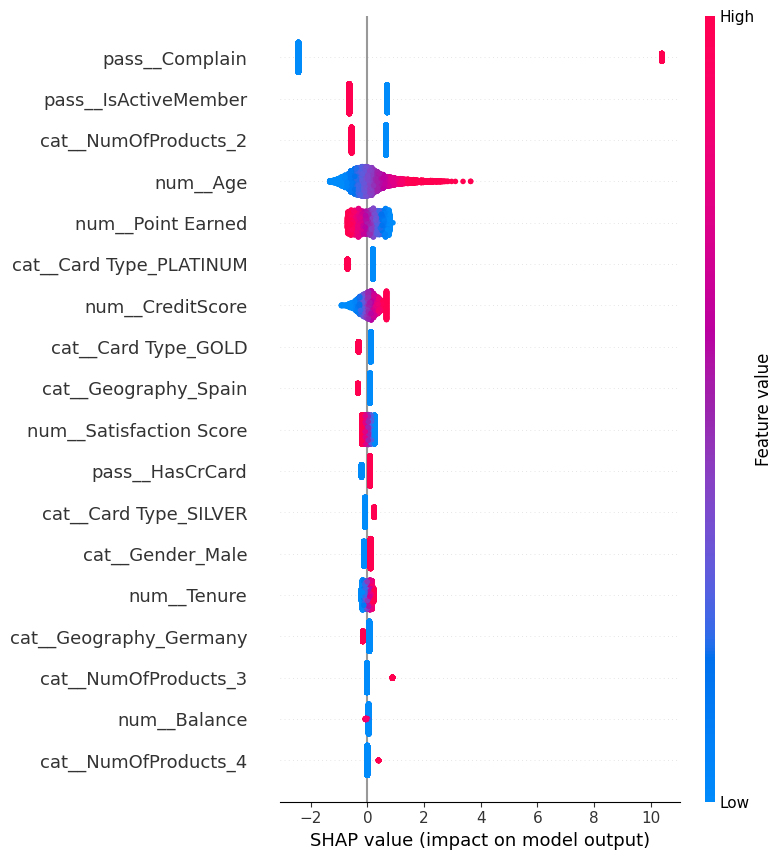

In [13]:
# =========================================================
# SHAP Analysis (logistic regression classifier)
# =========================================================

explainer = shap.LinearExplainer(
    model,
    X_train_transformed_df
)

shap_values = explainer.shap_values(X_train_transformed_df)

shap.summary_plot(shap_values, X_train_transformed_df)

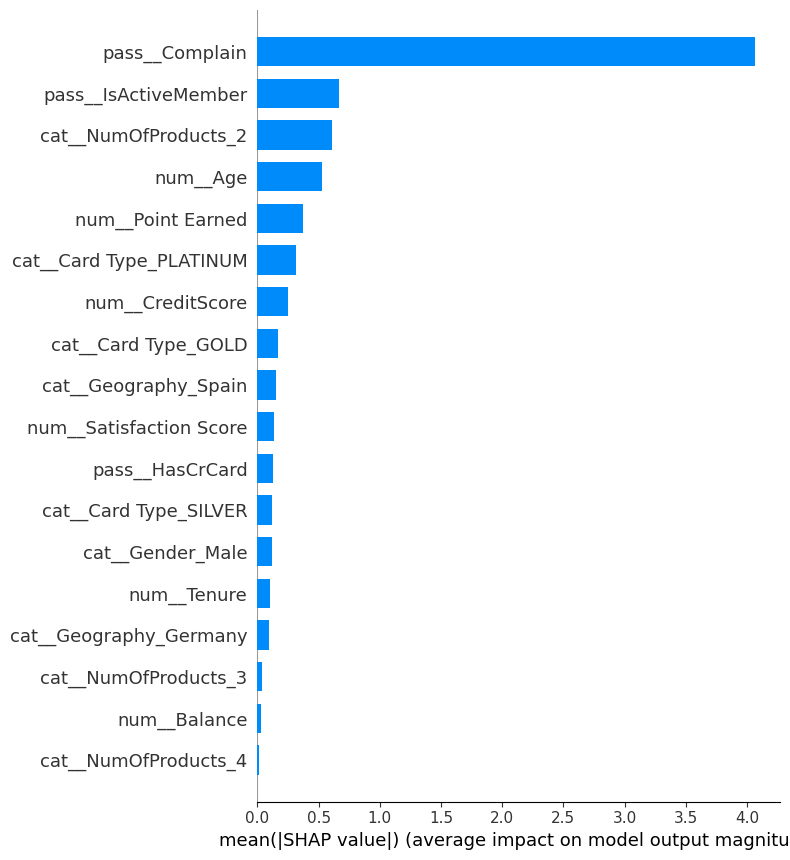

In [14]:
shap.summary_plot(
    shap_values,
    X_train_transformed_df,
    plot_type="bar"
)

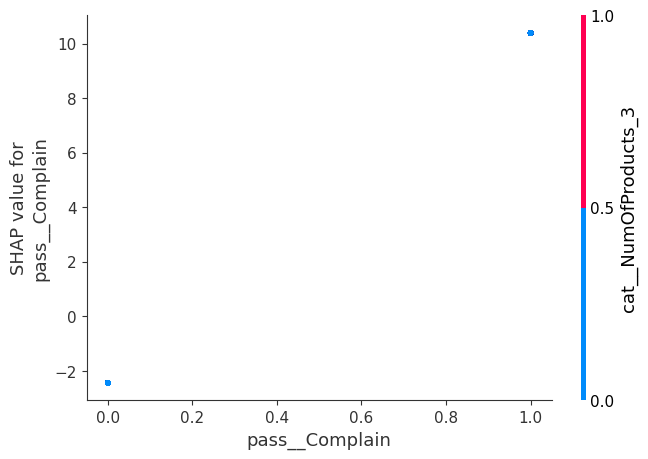

In [24]:
shap.dependence_plot(
    "pass__Complain",
    shap_values,
    X_train_transformed_df
)

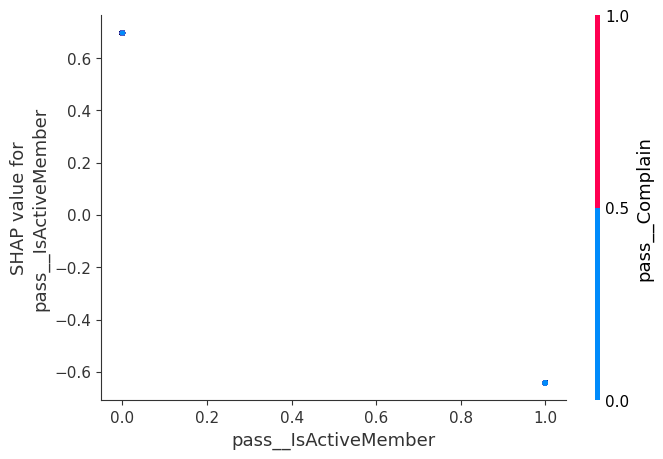

In [25]:
shap.dependence_plot(
    "pass__IsActiveMember",
    shap_values,
    X_train_transformed_df
)

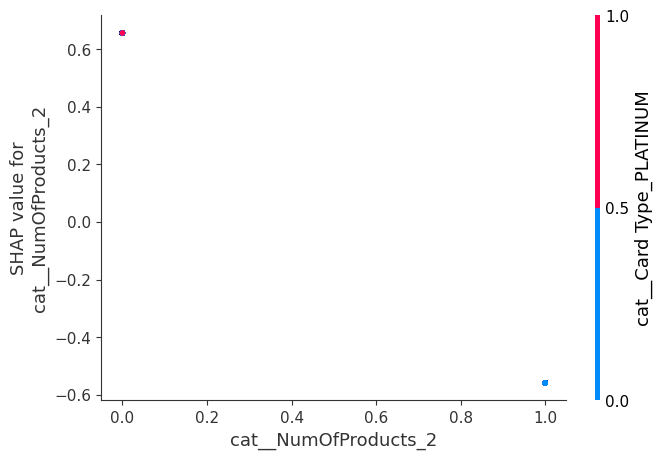

In [26]:
# nada
shap.dependence_plot(
    "cat__NumOfProducts_2",
    shap_values,
    X_train_transformed_df
)

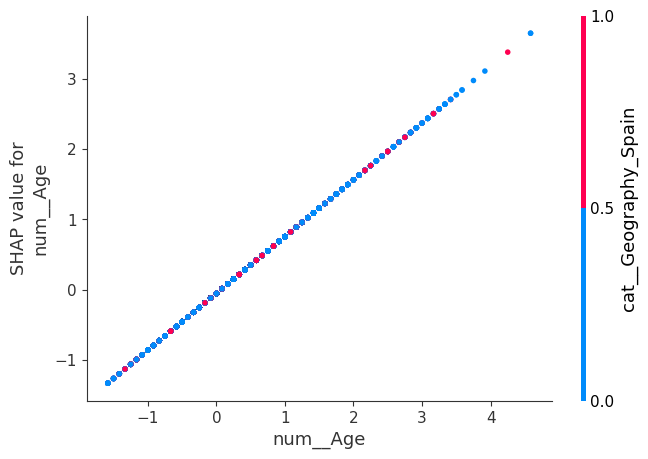

In [27]:
shap.dependence_plot(
    "num__Age",
    shap_values,
    X_train_transformed_df
)

In [19]:
X_train_transformed_df.columns

Index(['cat__Card Type_GOLD', 'cat__Card Type_PLATINUM',
       'cat__Card Type_SILVER', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3',
       'cat__NumOfProducts_4', 'cat__Geography_Germany',
       'cat__Geography_Spain', 'cat__Gender_Male', 'num__Balance',
       'num__Point Earned', 'num__CreditScore', 'num__Age', 'num__Tenure',
       'num__Satisfaction Score', 'pass__HasCrCard', 'pass__IsActiveMember',
       'pass__Complain'],
      dtype='object')

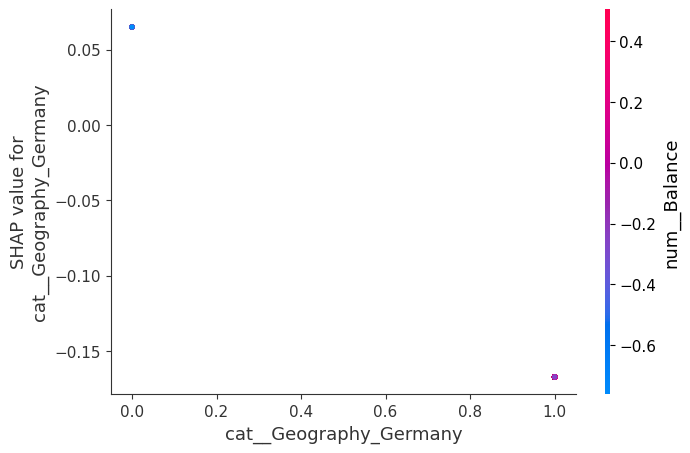

In [20]:
shap.dependence_plot(
    "cat__Geography_Germany",
    shap_values,
    X_train_transformed_df
)

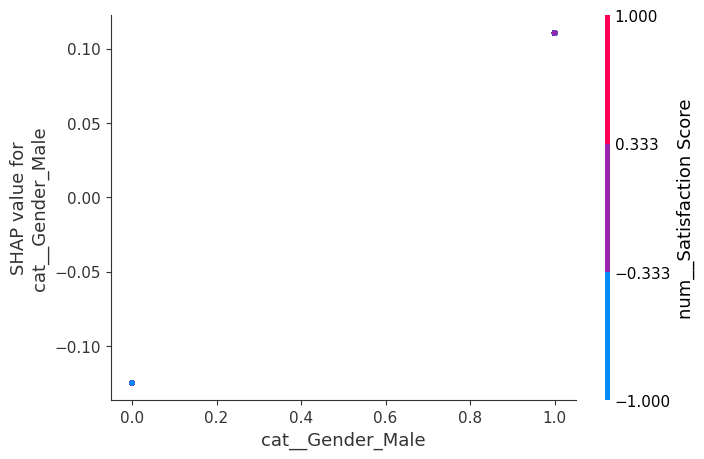

In [21]:
shap.dependence_plot(
    "cat__Gender_Male",
    shap_values,
    X_train_transformed_df
)

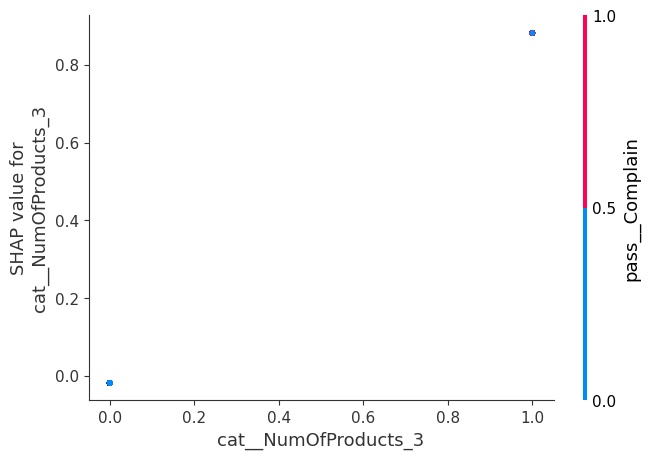

In [23]:
shap.dependence_plot(
    "cat__NumOfProducts_3",
    shap_values,
    X_train_transformed_df
)